# Chapter 3 - Unsupervised Learning and Preprocessing

This notebook contains code reproductions, theoretical explanations, and discussions based on Chapter 3 of *Introduction to Machine Learning with Python: A Guide for Data Scientists* by Andreas C. Müller and Sarah Guido.

## Chapter Summary

This chapter introduces unsupervised learning methods and data preprocessing techniques. Unlike supervised learning, unsupervised learning works without labeled target values and focuses on discovering hidden patterns within data.

The chapter covers scaling and preprocessing methods, dimensionality reduction techniques such as PCA and NMF, as well as clustering algorithms including k-Means, Agglomerative Clustering, and DBSCAN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

%matplotlib inline

# Preprocessing and Scaling

Many machine learning algorithms perform better when features are on similar scales. Preprocessing transforms data into a format that is easier for algorithms to learn from.

Common preprocessing methods include StandardScaler, MinMaxScaler, RobustScaler, and Normalizer.

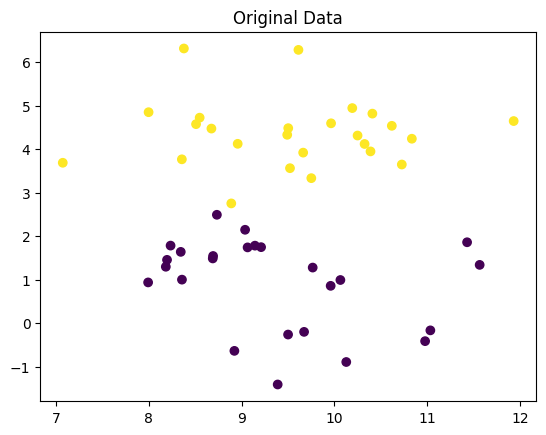

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=50,
    centers=2,
    random_state=4,
    cluster_std=1
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Original Data")
plt.show()

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X)

X_scaled = scaler.transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (50, 2)
Scaled shape: (50, 2)


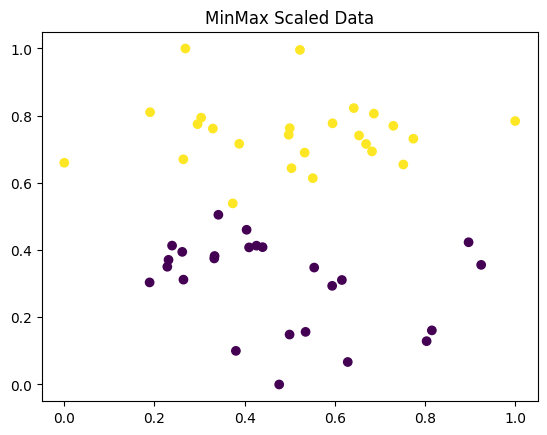

In [4]:
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y
)

plt.title("MinMax Scaled Data")
plt.show()

### Discussion

MinMaxScaler transforms features so that all values fall within a specific range, usually between 0 and 1.

Scaling is important because some machine learning algorithms are sensitive to differences in feature magnitudes.

# StandardScaler

StandardScaler transforms features so that they have a mean of zero and a standard deviation of one.

This preprocessing technique is commonly used before applying algorithms such as SVMs and Neural Networks.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.30048277 -0.44697936]
 [-0.54529266  0.05431534]
 [-1.06759174 -0.52067704]
 [-0.51315233 -1.69535026]
 [-1.40504229 -0.88313664]]


### Discussion

Standardization helps ensure that each feature contributes equally during model training. Without scaling, features with larger values may dominate the learning process.

# Principal Component Analysis (PCA)

Principal Component Analysis is a dimensionality reduction technique that transforms data into a smaller set of new features called principal components.

The goal is to retain as much information as possible while reducing the number of dimensions.

In [6]:
cancer = load_breast_cancer()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(cancer.data)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca.fit(X_scaled)

X_pca = pca.transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (569, 30)
Reduced shape: (569, 2)


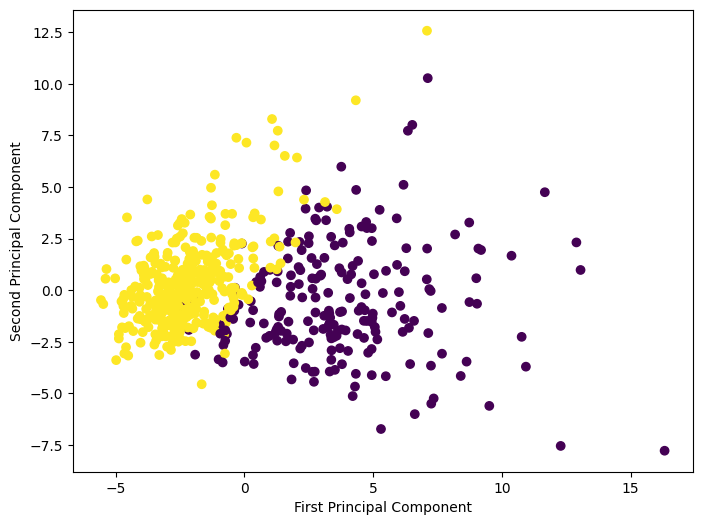

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cancer.target
)

plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")

plt.show()

### Discussion

PCA reduces the dimensionality of the dataset while preserving as much variance as possible.

The resulting components can help visualize complex datasets and reduce computational costs.

# Non-Negative Matrix Factorization (NMF)

NMF is a dimensionality reduction technique that decomposes data into a set of non-negative components.

Unlike PCA, NMF often produces components that are easier to interpret because all values remain non-negative.

In [9]:
from sklearn.decomposition import NMF

nmf = NMF(
    n_components=10,
    random_state=42,
    max_iter=1000
)

X_nmf = nmf.fit_transform(
    np.abs(X_scaled)
)

print("Original shape:", X_scaled.shape)
print("NMF shape:", X_nmf.shape)

Original shape: (569, 30)
NMF shape: (569, 10)


### Discussion

NMF reduces the dimensionality of data by representing observations as combinations of non-negative components.

This approach is commonly used in text mining, image analysis, and recommendation systems.

# t-SNE

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a visualization technique used to represent high-dimensional data in two dimensions.

Unlike PCA, t-SNE focuses on preserving local relationships between data points.

In [10]:
from sklearn.datasets import load_digits

digits = load_digits()

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(
    random_state=42
)

digits_tsne = tsne.fit_transform(
    digits.data
)

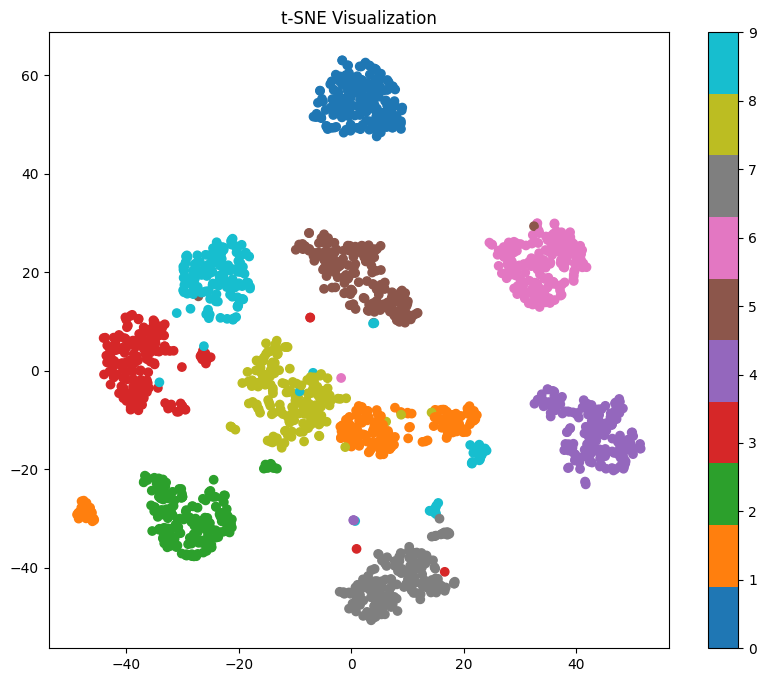

In [12]:
plt.figure(figsize=(10, 8))

plt.scatter(
    digits_tsne[:, 0],
    digits_tsne[:, 1],
    c=digits.target,
    cmap="tab10"
)

plt.colorbar()

plt.title("t-SNE Visualization")

plt.show()

### Discussion

t-SNE helps visualize complex datasets by grouping similar observations together.

Although it is useful for visualization, it is generally not used as a preprocessing step for machine learning models.

# k-Means Clustering

k-Means is one of the most widely used clustering algorithms.

The algorithm partitions data into k groups by assigning each observation to the nearest cluster center.

In [13]:
from sklearn.cluster import KMeans

X, y = make_blobs(
    random_state=1
)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [14]:
print("Cluster memberships:\n{}".format(
    kmeans.labels_
))

Cluster memberships:
[1 0 0 0 2 2 2 0 1 1 0 0 2 1 2 2 2 1 0 0 2 0 2 1 0 2 2 1 1 2 1 1 2 1 0 2 0
 0 0 2 2 0 1 0 0 2 1 1 1 1 0 2 2 2 1 2 0 0 1 1 0 2 2 0 0 2 1 2 1 0 0 0 2 1
 1 0 2 2 1 0 1 0 0 2 1 1 1 1 0 1 2 1 1 0 0 2 2 1 2 1]


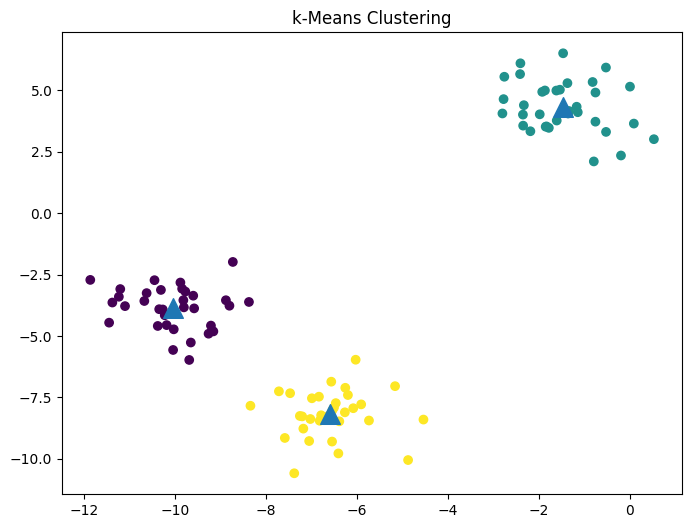

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans.labels_,
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="^",
    s=200
)

plt.title("k-Means Clustering")

plt.show()

### Discussion

k-Means groups observations based on similarity. Each cluster is represented by its centroid, which is updated iteratively until convergence.

The number of clusters must be specified before training.

# Agglomerative Clustering

Agglomerative Clustering is a hierarchical clustering method.

The algorithm starts with each observation as its own cluster and gradually merges clusters until the desired number of groups is reached.

In [17]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3
)

assignment = agg.fit_predict(X)

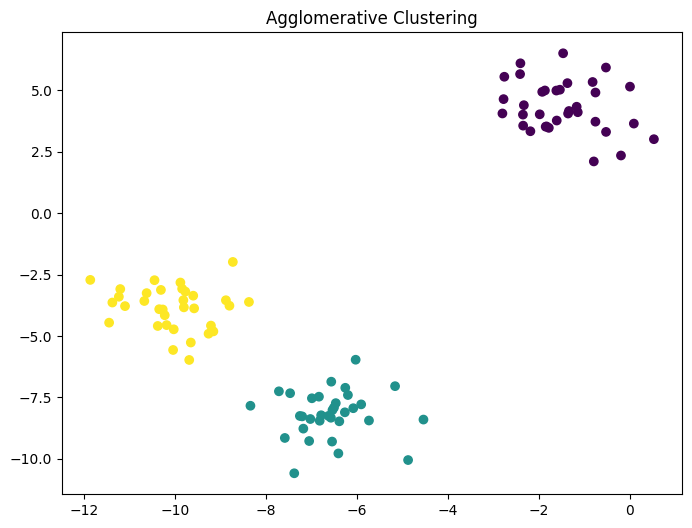

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=assignment,
    cmap="viridis"
)

plt.title("Agglomerative Clustering")

plt.show()

### Discussion

Hierarchical clustering provides a structured view of how clusters are formed.

Unlike k-Means, it does not rely on centroid updates and can reveal relationships between groups at different levels.

### Discussion

Hierarchical clustering provides a structured view of how clusters are formed.

Unlike k-Means, it does not rely on centroid updates and can reveal relationships between groups at different levels.

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()

clusters = dbscan.fit_predict(X)

### Discussion

DBSCAN identifies clusters based on density rather than distance to a centroid.

One advantage of DBSCAN is its ability to detect noise and discover clusters with irregular shapes. However, its performance depends heavily on parameter selection.

# Comparing Clustering Methods

Different clustering algorithms approach the grouping process in different ways.

- k-Means uses centroids and requires the number of clusters in advance.
- Agglomerative Clustering builds a hierarchy of clusters through repeated merging.
- DBSCAN groups observations based on density and can identify noise points.

The choice of clustering algorithm depends on the structure of the dataset and the desired outcome.

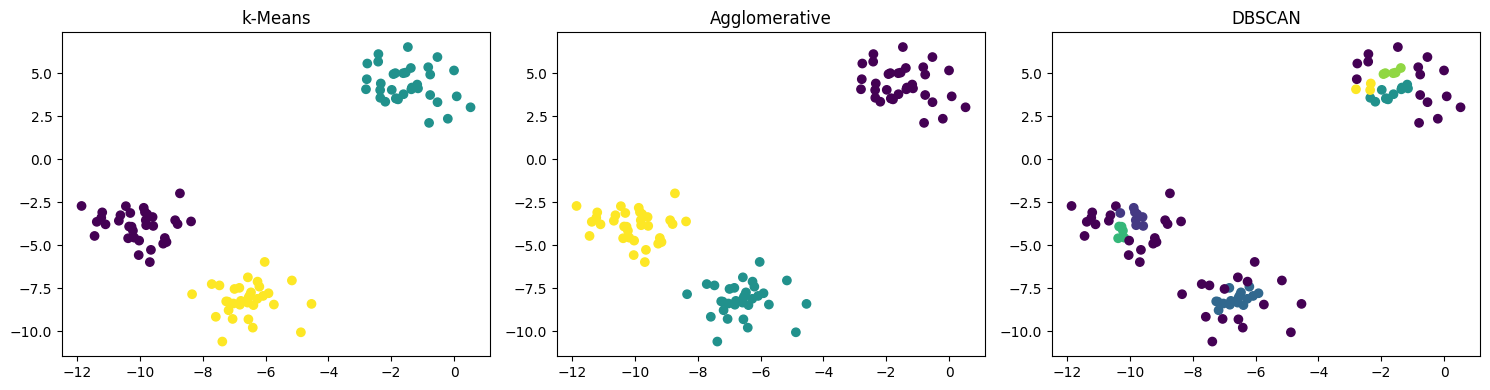

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans.labels_,
    cmap="viridis"
)
axes[0].set_title("k-Means")

axes[1].scatter(
    X[:, 0],
    X[:, 1],
    c=assignment,
    cmap="viridis"
)
axes[1].set_title("Agglomerative")

axes[2].scatter(
    X[:, 0],
    X[:, 1],
    c=clusters,
    cmap="viridis"
)
axes[2].set_title("DBSCAN")

plt.tight_layout()
plt.show()

### Discussion

The visualization highlights how different clustering methods partition the same dataset.

Although the results may appear similar for simple datasets, differences become more noticeable when working with complex or noisy data.

# Key Takeaways

This chapter introduced several important unsupervised learning techniques.

Main topics covered:

- Feature scaling and preprocessing
- Principal Component Analysis (PCA)
- Non-Negative Matrix Factorization (NMF)
- t-SNE visualization
- k-Means Clustering
- Agglomerative Clustering
- DBSCAN

These techniques help uncover hidden structures in data and prepare datasets for machine learning tasks.

# Conclusion

This chapter explored unsupervised learning techniques and preprocessing methods commonly used in machine learning.

Preprocessing methods such as MinMaxScaler and StandardScaler help improve data quality and ensure that features are on comparable scales. Dimensionality reduction techniques such as PCA and NMF simplify complex datasets while preserving important information.

The chapter also introduced several clustering algorithms, including k-Means, Agglomerative Clustering, and DBSCAN. Each algorithm provides a different approach to grouping data and can be useful depending on the characteristics of the dataset.

Understanding these methods is important because many real-world machine learning projects involve unlabeled data and require preprocessing before model development.